# Test 1: full population inference

In [1]:
import numpy as np

In [2]:
import torch

In [3]:
import emcee
import corner as DFM
import matplotlib.pyplot as plt

In [4]:
from px2cosmo import fm as FM 
from px2cosmo import util as UT

## generate mock observation

In [5]:
phi_true = np.array([-1.65, -1.5, -0.2, -19.5]) # fit by eye to zeus21 output

# sample LF 
X_obs = FM.forwardmodel(phi_true, name='test1')

In [6]:
_X_obs = torch.tensor(X_obs.astype(np.float32)) #.to('mps')
_logN_obs = torch.tensor(np.log(X_obs.shape[0]).astype(np.float32))

## load NDEs of $p(\log N|\phi)$ and $p(X|\phi)$

In [7]:
p_logN_phi = torch.load('/Users/chang/data/px2cosmo/test1/mock1_p_logN_phi.pt',  weights_only=False) 
p_X_phi = torch.load('/Users/chang/data/px2cosmo/test1/mock1_p_X_phi.pt', weights_only=False)

## set up posterior

In [8]:
def log_prior(phi): 
    alpha, beta, gamma, Muv_s = phi
    if -1.8 < alpha < -1.5 and -1.8 < beta < -1.2 and -0.4 < gamma < 0 and -22 < Muv_s < -18: 
        return 0.
    return -np.inf

In [9]:
def log_posterior(phi, silent=True): 
    lp = log_prior(phi)
    if not np.isfinite(lp):
        return -np.inf

    # log likelihood
    _phi = torch.tensor(phi.astype(np.float32)) #.to('mps')
    logp = np.sum(p_X_phi.log_prob_batched(_X_obs, _phi).cpu().numpy())

    # log Poisson
    logp2 = p_logN_phi.log_prob(_logN_obs, _phi).cpu().numpy()
    if not silent: print(logp, logp2)
        
    return logp + logp2

In [10]:
# quick sanity check 
print(log_posterior(phi_true, silent=False))

-18410.328 [3.3860173]
[-18406.941]


In [15]:
_alpha = np.random.uniform(-1.8, -1.5) 
_beta = np.random.uniform(-1.8, -1.2)
_gamma = np.random.uniform(-0.4, 0.0) 
_Muv_s = np.random.uniform(-22., -18.)
_phi = np.array([_alpha, _beta, _gamma, _Muv_s])
print(log_posterior(_phi, silent=False))

-18698.383 [-13.249548]
[-18711.633]


In [16]:
%timeit log_posterior(phi_true)

56.5 ms ± 212 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [17]:
ndim, nwalkers = 4, 10
var = np.array([0.1, 0.1, 0.1, 0.1])
p0 = phi_true[None,:] + var[None,:]*np.random.randn(nwalkers, ndim)

In [18]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
_ = sampler.run_mcmc(p0, 1000, progress=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [10:01<00:00,  1.66it/s]


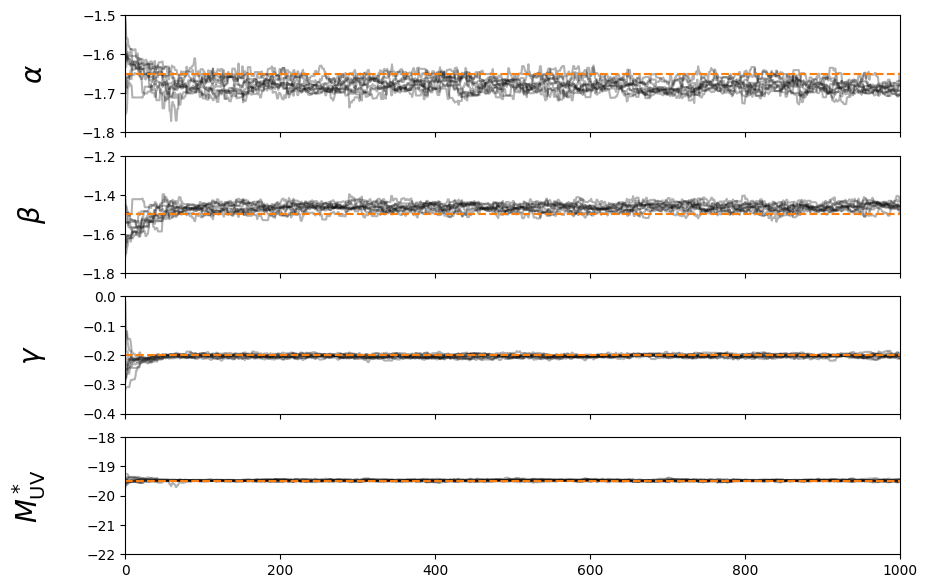

In [19]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.plot([0, samples.shape[0]], [phi_true[i], phi_true[i]], c='C1', ls='--')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel([r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$'][i], fontsize=20)
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_ylim([(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18)][i])

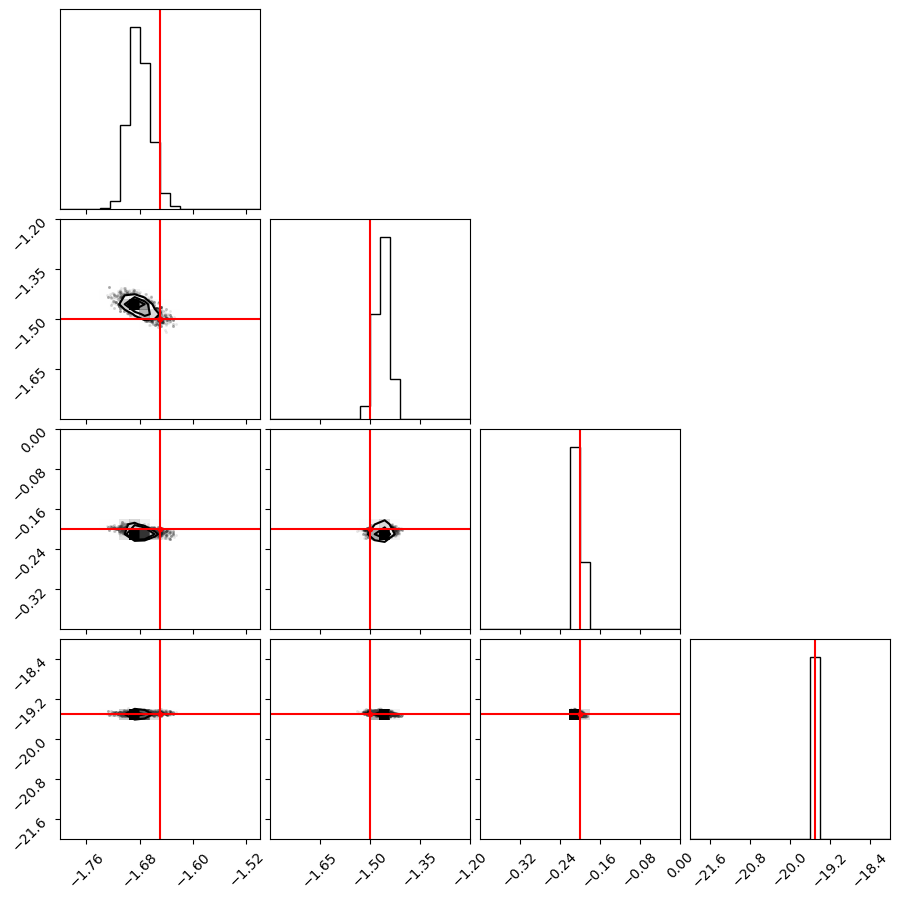

In [20]:
fig = DFM.corner(sampler.flatchain[5000:,:], range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18)])
DFM.overplot_points(fig, [phi_true], color='red')
DFM.overplot_lines(fig, phi_true, color='red')
#DFM.overplot_lines(fig, np.median(sampler.flatchain[5000:,:], axis=0), color='blue')

In [22]:
log_posterior(phi_true, silent=False)

-18410.328 [3.3860173]


array([-18406.941], dtype=float32)

In [21]:
log_posterior(np.median(sampler.flatchain[5000:,:], axis=0), silent=False)

-18407.512 [3.3233573]


array([-18404.188], dtype=float32)

(2e-05, 0.1)

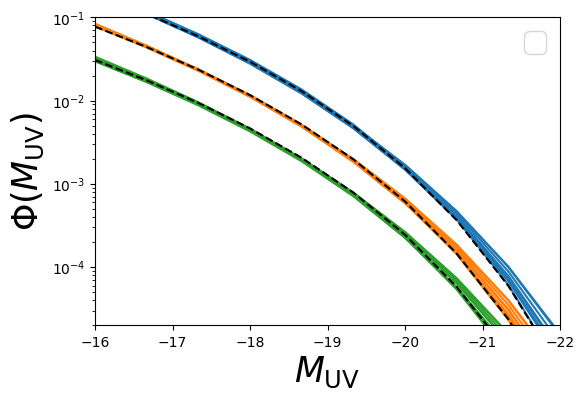

In [32]:
fig = plt.figure(figsize=(6,4))
sub = fig.add_subplot(111)

phi_amp = 6e-3
Muv_bin = np.linspace(-16, -22, 10)
for i, z0 in enumerate([5., 7., 9.]): 
    for j in range(nwalkers): 
        sub.plot(Muv_bin, phi_amp*UT.LF(Muv_bin, z0, sampler.chain[j,-1,:]), c='C%i' % i)

    sub.plot(Muv_bin, phi_amp*UT.LF(Muv_bin, z0, phi_true), c='k', ls='--')
        

sub.legend(loc='upper right', handletextpad=0.1, fontsize=20)
sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
sub.set_xlim(-16, -22)
sub.set_yscale('log')
sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
plt.ylim(2e-5, 1e-1)

In [36]:
np.hstack([np.arange(100), np.arange(100)]).shape

(200,)